# TalentTrack.
**Group 3:** Daffa Ahmad Pangreksa (159) · Halilatunnisa (130) · Naura Kanaya Putri Masruri (138)  
**Class:** 2024-INT | Data Warehouse | UNESA  

TalentTrack aims to build an OLAP-based data mart for analyzing labor market demand trends using job posting data collected from multiple recruitment platforms such as LinkedIn. The data used in this project combines a large historical dataset with periodically scraped job postings, processed through ETL workflows, NLP-based skill extraction using GLiNER and also  skill demand forecasting. The data mart is implemented using Atoti and consists of three main cubes:
1. `JobPostings`used for supports the analysis of job posting volume and job characteristics.
2. `SkillDemand`used for examines skill demand across different time periods, locations and job categories.
3. `SkillForecast`used for provides predictions of future skill demand trends for the coming weeks.

TalentTrack is expected to deliver more timely, structured and data-driven insights into labor market dynamics compared to traditional labor market reports, helping users better understand evolving workforce demands, emerging skills and hiring trends across industries and regions.

---
**Prerequisites:**
1. pip install atoti[all] sqlalchemy psycopg2-binary python-dotenv pandas numpy
2. Make sure that a .env file is placed in the talent-trackk/ directory containing the required PostgreSQL/Supabase credentials.

## Installation 

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "atoti[jupyterlab]"], check=True)

CompletedProcess(args=['C:\\Users\\Naura Kanaya\\Downloads\\TalentTrack\\atoti-env\\Scripts\\python.exe', '-m', 'pip', 'install', 'atoti[jupyterlab]'], returncode=0)

In [2]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "python-dotenv", "sqlalchemy", "psycopg2-binary"], check=True)

CompletedProcess(args=['C:\\Users\\Naura Kanaya\\Downloads\\TalentTrack\\atoti-env\\Scripts\\python.exe', '-m', 'pip', 'install', 'python-dotenv', 'sqlalchemy', 'psycopg2-binary'], returncode=0)

In [3]:
import subprocess, sys
result = subprocess.run([sys.executable, "-m", "pip", "show", "atoti"], capture_output=True, text=True)
print(result.stdout)

Name: atoti
Version: 0.9.14
Summary: Explore metrics across hundreds of dimensions, analyze live data at its most granular level and perform what-if simulations at unparalleled speed
Home-page: https://www.atoti.io
Author: ActiveViam
Author-email: ActiveViam <atoti-dev@activeviam.com>
License: 
Location: C:\Users\Naura Kanaya\Downloads\TalentTrack\atoti-env\Lib\site-packages
Requires: atoti-client, atoti-client-parquet, atoti-server, atoti-server-parquet, jdk4py
Required-by: 



## Environment Setup

In [4]:
import os
from pathlib import Path
from dotenv import load_dotenv

root = Path(os.getcwd()).parent  
sys.path.insert(0, str(root))

In [5]:
load_dotenv(root / ".env", override=True)
print("PGHOST:", os.getenv("PGHOST"))
print("PGDATABASE:", os.getenv("PGDATABASE"))

PGHOST: aws-1-ap-south-1.pooler.supabase.com
PGDATABASE: postgres


## Import Libraries & Database Connection

In [6]:
import pandas as pd
import numpy as np
import atoti as tt
from sqlalchemy import create_engine

DB_URL = (
    f"postgresql://{os.getenv('PGUSER')}:{os.getenv('PGPASSWORD')}"
    f"@{os.getenv('PGHOST')}:{os.getenv('PGPORT', 5432)}/{os.getenv('PGDATABASE')}"
)
engine = create_engine(DB_URL, pool_pre_ping=True)
print("DB engine created")

Welcome to Atoti 0.9.14!

By using this community edition, you agree with the license available at https://docs.activeviam.com/products/atoti/python-sdk/latest/eula.html.
Browse the official documentation at https://docs.activeviam.com/products/atoti/python-sdk.
Join the community at https://www.atoti.io/register.

Atoti collects telemetry data, which is used to help understand how to improve the product.
If you don't wish to send usage data, you can request a trial license at https://www.atoti.io/evaluation-license-request.

You can hide this message by setting the `ATOTI_HIDE_EULA_MESSAGE` environment variable to True.
DB engine created


## Load Data from PostgreSQL

### Table ListTable List

In [7]:
from sqlalchemy import inspect
import pandas as pd

inspector = inspect(engine)
tables = inspector.get_table_names()

print("TABLES:")
for t in tables:
    print("-", t)

TABLES:
- dim_time
- dim_location
- dim_company
- dim_position
- dim_platform
- fact_job_posting
- fact_job_posting_default
- dim_skill
- bridge_job_skill
- forecast_skill_demand
- fact_job_posting_2023
- fact_job_posting_2024
- fact_job_posting_2025
- fact_job_posting_2026


### Schema & Sample Data

In [8]:
for table in tables:
    print(f"\nTABLE: {table}")

    columns = inspector.get_columns(table)
    col_data = []
    for col in columns:
        col_data.append({
            "column": col["name"],
            "type": str(col["type"])
        })
    display(pd.DataFrame(col_data))

    # Data sample
    try:
        sample_df = pd.read_sql(
            f"SELECT * FROM {table} LIMIT 3",
            engine
        )
        display(sample_df)

    except Exception as e:
        print("Sample read error:", e)


TABLE: dim_time


,column,type
0,time_id,INTEGER
1,date,DATE
2,week,INTEGER
3,month,INTEGER
4,quarter,INTEGER
5,year,INTEGER
6,week_label,TEXT


,time_id,date,week,month,quarter,year,week_label
0,1,2023-01-01,52,1,1,2023,2023-W52
1,2,2023-01-02,1,1,1,2023,2023-W01
2,3,2023-01-03,1,1,1,2023,2023-W01



TABLE: dim_location


,column,type
0,location_id,INTEGER
1,city,TEXT
2,country,TEXT
3,region,TEXT


...

,column,type
0,job_id,BIGINT
1,time_id,INTEGER
2,location_id,INTEGER
3,company_id,INTEGER
4,position_id,INTEGER
5,platform_id,INTEGER
6,posting_count,INTEGER
7,job_age_days,INTEGER
8,has_salary,BOOLEAN
9,is_remote,BOOLEAN


,job_id,time_id,location_id,company_id,position_id,platform_id,posting_count,job_age_days,has_salary,is_remote,salary_min,salary_max,source_hash,raw_title
0,152,1075,110,116,146,1,1,168,False,False,None,None,c462bb2764360aa5e861e02e41b9323b,Cleaner
1,153,866,111,117,147,1,1,377,False,False,None,None,0c4d2528ca803b8b4f0cb4c7423cc808,In Vivo Scientist
2,154,1073,110,118,148,1,1,170,False,False,None,None,f6f2af3650c58f9b52d0f15df1156022,2D Artist



TABLE: fact_job_posting_2026


,column,type
0,job_id,BIGINT
1,time_id,INTEGER
2,location_id,INTEGER
3,company_id,INTEGER
4,position_id,INTEGER
5,platform_id,INTEGER
6,posting_count,INTEGER
7,job_age_days,INTEGER
8,has_salary,BOOLEAN
9,is_remote,BOOLEAN


,job_id,time_id,location_id,company_id,position_id,platform_id,posting_count,job_age_days,has_salary,is_remote,salary_min,salary_max,source_hash,raw_title
0,151,1234,110,115,145,1,1,9,False,False,None,None,6ef2761351dee534ad0ecf2d08b67bb9,"Junior Project Manager (Remote, Contract)"
1,155,1234,110,115,149,1,1,9,False,False,None,None,c9050d4a7b8b0cab62cef861121ec739,"Middle Project Manager (Remote, Contract)"
2,156,1223,112,119,150,1,1,20,False,False,None,None,da31f38d6c50c247e9dac9e4031f6de8,E&S Senior Manager / Director - Mekong Capital


### Load & Clean fact_job_posting

In [9]:
fact_df = pd.read_sql(
    """
    SELECT
        f.job_id,
        f.time_id,
        f.location_id,
        f.company_id,
        f.position_id,
        f.platform_id,

        f.posting_count,
        f.job_age_days,

        CASE
            WHEN f.has_salary THEN 1
            ELSE 0
        END AS has_salary,

        CASE
            WHEN f.is_remote THEN 1
            ELSE 0
        END AS is_remote,

        f.salary_min,
        f.salary_max,

        f.raw_title,
        f.source_hash,

        dt.date,
        dt.week,
        dt.month,
        dt.quarter,
        dt.year,
        dt.week_label,

        dl.city,
        dl.country,
        dl.region,

        dc.company_name,

        dp.normalized_job_title,
        dp.job_level,
        dp.job_category,

        dpl.platform_name

    FROM fact_job_posting f

    JOIN dim_time dt
        ON f.time_id = dt.time_id

    JOIN dim_location dl
        ON f.location_id = dl.location_id

    JOIN dim_company dc
        ON f.company_id = dc.company_id

    JOIN dim_position dp
        ON f.position_id = dp.position_id

    JOIN dim_platform dpl
        ON f.platform_id = dpl.platform_id
    """,
    engine
)

# remove duplicates
fact_df = fact_df.drop_duplicates(subset=["job_id"])

# datetime
fact_df["date"] = pd.to_datetime(fact_df["date"])

# numeric cleanup
numeric_cols = [
    "salary_min",
    "salary_max",
    "posting_count",
    "job_age_days"
]

for col in numeric_cols:
    fact_df[col] = pd.to_numeric(
        fact_df[col],
        errors="coerce"
    )

# fill null numeric
fact_df = fact_df.fillna({
    "salary_min": 0,
    "salary_max": 0,
    "posting_count": 0,
    "job_age_days": 0
})

# fill object nulls
for col in fact_df.select_dtypes(include="object"):
    fact_df[col] = fact_df[col].fillna("Unknown")

print(f"fact_job_posting : {len(fact_df):,} rows")
fact_df.head()

fact_job_posting : 2,087 rows


,job_id,time_id,location_id,company_id,position_id,platform_id,posting_count,job_age_days,has_salary,is_remote,...,year,week_label,city,country,region,company_name,normalized_job_title,job_level,job_category,platform_name
0,1,473,1,1,1,1,1,770,0,0,...,2024,2024-W16,Princeton,United States,North America,Corcoran Sawyer Smith,marketing coordinator,Manager,Management,LinkedIn
1,2,467,2,2,2,1,1,776,1,0,...,2024,2024-W15,Fort Collins,United States,North America,Unknown,mental health therapist/counselor,Unknown,Healthcare,LinkedIn
2,3,472,3,3,3,1,1,771,1,0,...,2024,2024-W16,Cincinnati,United States,North America,The National Exemplar,assitant restaurant manager,Manager,Management,LinkedIn
3,4,468,4,4,4,1,1,775,1,0,...,2024,2024-W15,New Hyde Park,United States,North America,"Abrams Fensterman, Llp",senior elder law / trusts and estates associat...,Junior,Legal,LinkedIn
4,5,474,5,2,5,1,1,769,1,0,...,2024,2024-W16,Burlington,United States,North America,Unknown,service technician,Unknown,Other,LinkedIn


### Load & Clean bridge_job_skill

In [10]:
skill_df = pd.read_sql(
    """
    SELECT
        b.job_id,
        b.skill_id,
        b.extraction_confidence,

        ds.skill_name,
        ds.skill_type,
        ds.skill_domain

    FROM bridge_job_skill b

    JOIN dim_skill ds
        ON b.skill_id = ds.skill_id
    """,
    engine
)

print(f"Rows loaded: {len(skill_df):,}")
skill_df.head()

skill_df["extraction_confidence"] = pd.to_numeric(
    skill_df["extraction_confidence"],
    errors="coerce"
)

skill_df["extraction_confidence"] = (
    skill_df["extraction_confidence"]
    .fillna(0)
)

skill_df = skill_df.drop_duplicates()

for col in skill_df.select_dtypes(include="object"):
    skill_df[col] = skill_df[col].fillna("Unknown")

print("skill_df cleaned successfully")
print(f"Total rows: {len(skill_df):,}")

Rows loaded: 6,930
skill_df cleaned successfully
Total rows: 6,930


### Load & Clean forecast_skill_demand 

In [11]:
forecast_df = pd.read_sql(
    """
    SELECT
        fsd.forecast_id,
        fsd.skill_id,

        ds.skill_name,
        ds.skill_type,
        ds.skill_domain,

        fsd.job_category,

        fsd.forecast_week_label,
        fsd.forecast_year,
        fsd.forecast_week,

        fsd.predicted_count,
        fsd.lower_bound,
        fsd.upper_bound,
        fsd.trend_score,

        fsd.model_name,
        fsd.generated_at

    FROM forecast_skill_demand fsd

    JOIN dim_skill ds
        ON fsd.skill_id = ds.skill_id
    """,
    engine
)

print(f"Rows loaded: {len(forecast_df):,}")
forecast_df.head()

forecast_numeric_cols = [
    "predicted_count",
    "lower_bound",
    "upper_bound",
    "trend_score"
]

for col in forecast_numeric_cols:
    forecast_df[col] = pd.to_numeric(
        forecast_df[col],
        errors="coerce"
    )

forecast_df = forecast_df.fillna({
    "predicted_count": 0,
    "lower_bound": 0,
    "upper_bound": 0,
    "trend_score": 0
})

forecast_df["generated_at"] = pd.to_datetime(
    forecast_df["generated_at"],
    errors="coerce"
)

for col in forecast_df.select_dtypes(include="object"):
    forecast_df[col] = forecast_df[col].fillna("Unknown")

forecast_df = forecast_df.drop_duplicates()

print("forecast_df cleaned successfully")
print(f"Total rows: {len(forecast_df):,}")

Rows loaded: 27,960
forecast_df cleaned successfully
Total rows: 27,960


### Merge & Clean skill_fact_df

In [12]:
skill_fact_df = skill_df.merge(
    fact_df,
    on="job_id",
    how="left"
)

# numeric cleanup
skill_fact_df["salary_min"] = pd.to_numeric(
    skill_fact_df["salary_min"],
    errors="coerce"
)

skill_fact_df["salary_max"] = pd.to_numeric(
    skill_fact_df["salary_max"],
    errors="coerce"
)

# safer midpoint calculation
skill_fact_df["salary_midpoint"] = (
    skill_fact_df[
        ["salary_min", "salary_max"]
    ]
    .mean(axis=1)
)

# fill missing midpoint
skill_fact_df["salary_midpoint"] = (
    skill_fact_df["salary_midpoint"]
    .fillna(0)
)

# measure helper
skill_fact_df["skill_count"] = 1

# remove duplicate job-skill rows
skill_fact_df = skill_fact_df.drop_duplicates(
    subset=["job_id", "skill_id"]
)

# fill object nulls
for col in skill_fact_df.select_dtypes(include="object"):
    skill_fact_df[col] = (
        skill_fact_df[col]
        .fillna("Unknown")
    )

print(f"skill_fact_df merged : {len(skill_fact_df):,} rows")
skill_fact_df.head(3)

skill_fact_df merged : 6,930 rows


,job_id,skill_id,extraction_confidence,skill_name,skill_type,skill_domain,time_id,location_id,company_id,position_id,...,city,country,region,company_name,normalized_job_title,job_level,job_category,platform_name,salary_midpoint,skill_count
0,1,1,0.3922,graphic design,Knowledge,urchade/gliner_small-v2.1,473,1,1,1,...,Princeton,United States,North America,Corcoran Sawyer Smith,marketing coordinator,Manager,Management,LinkedIn,0.0,1
1,1,2,0.6282,adobe creative cloud,Knowledge,urchade/gliner_small-v2.1,473,1,1,1,...,Princeton,United States,North America,Corcoran Sawyer Smith,marketing coordinator,Manager,Management,LinkedIn,0.0,1
2,1,3,0.3554,indesign,Knowledge,urchade/gliner_small-v2.1,473,1,1,1,...,Princeton,United States,North America,Corcoran Sawyer Smith,marketing coordinator,Manager,Management,LinkedIn,0.0,1


## Final Cleanup Before Atoti

In [13]:
# clean fact_df
string_cols_fact = [
    "city",
    "country",
    "region",
    "company_name",
    "job_category",
    "job_level",
    "normalized_job_title",
    "platform_name"
]

for col in string_cols_fact:
    fact_df[col] = fact_df[col].fillna("Unknown")

fact_df["salary_min"] = fact_df["salary_min"].fillna(0)
fact_df["salary_max"] = fact_df["salary_max"].fillna(0)

# clean skill_fact_df
str_cols = [
    "skill_domain",
    "skill_type",
    "skill_name",
    "job_category",
    "job_level",
    "normalized_job_title",
    "region",
    "country",
    "city",
    "week_label",
    "platform_name",
    "company_name"
]

for col in str_cols:
    if col in skill_fact_df.columns:
        skill_fact_df[col] = skill_fact_df[col].fillna("Unknown")

# integer columns
int_cols = ["year", "quarter", "month", "week"]

for col in int_cols:
    if col in skill_fact_df.columns:
        skill_fact_df[col] = (
            skill_fact_df[col]
            .fillna(0)
            .astype(int)
        )

skill_fact_df["extraction_confidence"] = (
    skill_fact_df["extraction_confidence"]
    .fillna(0.0)
)

skill_fact_df["salary_midpoint"] = (
    skill_fact_df["salary_midpoint"]
    .fillna(0.0)
)

print("Final cleanup completed")

Final cleanup completed


## Create an Atoti Session

In [14]:
session = tt.Session.start(
    tt.SessionConfig(
        port=9090,
        user_content_storage="./content"
    )
)

print("Atoti session started")
print("Dashboard URL:", session.url)

Atoti session started
Dashboard URL: http://localhost:9090


## Cube 1: JobPostings
General analysis includes job posting volume, remote work rate, and salary coverage, analyzed across platforms, regions, and time periods to identify labor market distribution patterns and dynamics.

In [15]:
fact_df["is_remote"] = fact_df["is_remote"].map({
    1: "Remote",
    0: "Onsite",
    True: "Remote",
    False: "Onsite"
})

fact_df["has_salary"] = fact_df["has_salary"].map({
    1: "With Salary",
    0: "No Salary",
    True: "With Salary",
    False: "No Salary"
})

fact_df[["is_remote", "has_salary"]] = (
    fact_df[["is_remote", "has_salary"]]
    .fillna("Unknown")
)

job_store = session.read_pandas(
    fact_df,
    table_name="job_postings",
    keys=["job_id"],
    default_values={
        "time_id": 0,
        "location_id": 0,
        "company_id": 0,
        "position_id": 0,
        "platform_id": 0,

        "year": 0,
        "quarter": 0,
        "month": 0,
        "week": 0,

        "week_label": "Unknown",

        "city": "Unknown",
        "country": "Unknown",
        "region": "Unknown",

        "company_name": "Unknown",

        "normalized_job_title": "Unknown",
        "job_level": "Unknown",
        "job_category": "Unknown",

        "platform_name": "Unknown",

        "salary_min": 0.0,
        "salary_max": 0.0,

        "posting_count": 0,
        "job_age_days": 0,

        "has_salary": "Unknown",
        "is_remote": "Unknown"
    }
)

print("job_store created")

job_store created


In [16]:
# CREATE CUBE
job_cube = session.create_cube(
    job_store,
    name="JobPostings"
)

h = job_cube.hierarchies
m = job_cube.measures

In [17]:
h["Time"] = [
    job_store["year"],
    job_store["quarter"],
    job_store["month"],
    job_store["week_label"]
]

h["Location"] = [
    job_store["region"],
    job_store["country"],
    job_store["city"]
]

h["Job"] = [
    job_store["job_category"],
    job_store["job_level"],
    job_store["normalized_job_title"]
]

h["Company"] = [
    job_store["company_name"]
]

h["Platform"] = [
    job_store["platform_name"]
]

h["Remote Status"] = [
    job_store["is_remote"]
]

h["Salary Status"] = [
    job_store["has_salary"]
]

m["Total Postings"] = tt.agg.sum(
    job_store["posting_count"]
)

m["Avg Salary Min"] = tt.agg.mean(
    job_store["salary_min"]
)

m["Avg Salary Max"] = tt.agg.mean(
    job_store["salary_max"]
)

m["Avg Job Age Days"] = tt.agg.mean(
    job_store["job_age_days"]
)

print("Cube JobPostings created successfully")

Cube JobPostings created successfully


## Cube 2: SkillDemand
Skill demand analysis identifies the most requested skills and examines their distribution across job categories, regions, and time periods to understand labor market demand patterns.

In [18]:
skill_store = session.read_pandas(
    skill_fact_df,

    table_name="skill_facts",

    keys=[
        "job_id",
        "skill_id"
    ],

    default_values={
        "skill_id": 0,

        "skill_domain": "Unknown",
        "skill_type": "Unknown",
        "skill_name": "Unknown",

        "job_category": "Unknown",
        "job_level": "Unknown",
        "normalized_job_title": "Unknown",

        "region": "Unknown",
        "country": "Unknown",
        "city": "Unknown",

        "year": 0,
        "quarter": 0,
        "month": 0,
        "week": 0,
        "week_label": "Unknown",

        "platform_name": "Unknown",

        "company_name": "Unknown",

        "extraction_confidence": 0.0,
        "salary_midpoint": 0.0,

        "skill_count": 0,
    }
)

In [19]:

# CREATE CUBE
skill_cube = session.create_cube(
    skill_store,
    name="SkillDemand"
)

In [20]:
sh = skill_cube.hierarchies
sm = skill_cube.measures

# HIERARCHIES
sh["Skill"] = [
    skill_store["skill_domain"],
    skill_store["skill_type"],
    skill_store["skill_name"]
]

sh["Job"] = [
    skill_store["job_category"],
    skill_store["job_level"],
    skill_store["normalized_job_title"]
]

sh["Location"] = [
    skill_store["region"],
    skill_store["country"],
    skill_store["city"]
]

sh["Time"] = [
    skill_store["year"],
    skill_store["quarter"],
    skill_store["month"],
    skill_store["week_label"]
]

sh["Platform"] = [
    skill_store["platform_name"]
]

sh["Company"] = [
    skill_store["company_name"]
]

# MEASURES
sm["Skill Postings"] = tt.agg.sum(
    skill_store["skill_count"]
)

sm["Avg Confidence"] = tt.agg.mean(
    skill_store["extraction_confidence"]
)

sm["Avg Salary Midpoint"] = tt.agg.mean(
    skill_store["salary_midpoint"]
)

print("Cube SkillDemand created successfully")

Cube SkillDemand created successfully


## Cube 3: SkillForecast
Forecasting results using Holt-Winters or linear trend models provide predictions of skill demand for the next 8 weeks.

In [21]:
forecast_store = session.read_pandas(
    forecast_df,

    table_name="skill_forecasts",

    keys=[
        "forecast_id"
    ],

    default_values={
        "forecast_id": 0,

        "skill_id": 0,

        "skill_name": "Unknown",
        "skill_type": "Unknown",
        "skill_domain": "Unknown",

        "job_category": "Unknown",

        "forecast_year": 0,
        "forecast_week": 0,
        "forecast_week_label": "Unknown",

        "model_name": "Unknown",

        "predicted_count": 0.0,
        "lower_bound": 0.0,
        "upper_bound": 0.0,
        "trend_score": 0.0,
    }
)

In [22]:
# CREATE CUBE
forecast_cube = session.create_cube(
    forecast_store,
    name="SkillForecast"
)

fh = forecast_cube.hierarchies
fm = forecast_cube.measures

In [23]:
# HIERARCHIES
fh["Skill"] = [
    forecast_store["skill_domain"],
    forecast_store["skill_type"],
    forecast_store["skill_name"]
]

fh["Job"] = [
    forecast_store["job_category"]
]

fh["Forecast Time"] = [
    forecast_store["forecast_year"],
    forecast_store["forecast_week"],
    forecast_store["forecast_week_label"]
]

fh["Model"] = [
    forecast_store["model_name"]
]

# MEASURES
fm["Predicted Postings"] = tt.agg.sum(
    forecast_store["predicted_count"]
)

fm["Forecast Lower"] = tt.agg.sum(
    forecast_store["lower_bound"]
)

fm["Forecast Upper"] = tt.agg.sum(
    forecast_store["upper_bound"]
)

fm["Forecast Range"] = (
    fm["Forecast Upper"]
    - fm["Forecast Lower"]
)

fm["Trend Score"] = tt.agg.mean(
    forecast_store["trend_score"]
)

print("Cube SkillForecast created successfully")

Cube SkillForecast created successfully


## Load Dimension Stores and Define Relationships

In [24]:
# LOAD DIMENSION TABLES
dim_time_df = pd.read_sql(
    "SELECT * FROM dim_time",
    engine
)

dim_location_df = pd.read_sql(
    "SELECT * FROM dim_location",
    engine
)

dim_company_df = pd.read_sql(
    "SELECT * FROM dim_company",
    engine
)

dim_position_df = pd.read_sql(
    "SELECT * FROM dim_position",
    engine
)

dim_platform_df = pd.read_sql(
    "SELECT * FROM dim_platform",
    engine
)

dim_skill_df = pd.read_sql(
    "SELECT * FROM dim_skill",
    engine
)

print("All dimension tables loaded")

dim_time_df["date"] = pd.to_datetime(
    dim_time_df["date"],
    errors="coerce"
)

dimension_dfs = [
    dim_time_df,
    dim_location_df,
    dim_company_df,
    dim_position_df,
    dim_platform_df,
    dim_skill_df
]

for df in dimension_dfs:

    for col in df.select_dtypes(include="object"):
        df[col] = df[col].fillna("Unknown")

    for col in df.select_dtypes(include="number"):
        df[col] = df[col].fillna(0)

# remove duplicates
for i in range(len(dimension_dfs)):
    dimension_dfs[i] = dimension_dfs[i].drop_duplicates()

print("Dimension tables cleaned")

All dimension tables loaded
Dimension tables cleaned


In [25]:
# LOAD DIMENSION STORES
dim_time_store = session.read_pandas(
    dim_time_df,
    table_name="dim_time",
    keys=["time_id"]
)

dim_location_store = session.read_pandas(
    dim_location_df,
    table_name="dim_location",
    keys=["location_id"]
)

dim_company_store = session.read_pandas(
    dim_company_df,
    table_name="dim_company",
    keys=["company_id"]
)

dim_position_store = session.read_pandas(
    dim_position_df,
    table_name="dim_position",
    keys=["position_id"]
)

dim_platform_store = session.read_pandas(
    dim_platform_df,
    table_name="dim_platform",
    keys=["platform_id"]
)

dim_skill_store = session.read_pandas(
    dim_skill_df,
    table_name="dim_skill",
    keys=["skill_id"]
)

print("Dimension stores created")

# STAR SCHEMA RELATIONSHIPS
# job_store relationships
job_store.join(
    dim_time_store,
    job_store["time_id"] == dim_time_store["time_id"]
)

job_store.join(
    dim_location_store,
    job_store["location_id"] == dim_location_store["location_id"]
)

job_store.join(
    dim_company_store,
    job_store["company_id"] == dim_company_store["company_id"]
)

job_store.join(
    dim_position_store,
    job_store["position_id"] == dim_position_store["position_id"]
)

job_store.join(
    dim_platform_store,
    job_store["platform_id"] == dim_platform_store["platform_id"]
)

# skill relationship
skill_store.join(
    dim_skill_store,
    skill_store["skill_id"] == dim_skill_store["skill_id"]
)

print("Star schema relationships created")

Dimension stores created
Star schema relationships created


In [26]:
session.tables.schema

```mermaid
erDiagram
  "job_postings" {
    non-null long PK "job_id"
    non-null long "time_id"
    non-null long "location_id"
    non-null long "company_id"
    non-null long "position_id"
    non-null long "platform_id"
    non-null long "posting_count"
    non-null long "job_age_days"
    non-null String "has_salary"
    non-null String "is_remote"
    non-null double "salary_min"
    non-null double "salary_max"
    non-null String "raw_title"
    non-null String "source_hash"
    non-null LocalDate "date"
    non-null long "week"
    non-null long "month"
    non-null long "quarter"
    non-null long "year"
    non-null String "week_label"
    non-null String "city"
    non-null String "country"
    non-null String "region"
    non-null String "company_name"
    non-null String "normalized_job_title"
    non-null String "job_level"
    non-null String "job_category"
    non-null String "platform_name"
  }
  "skill_facts" {
    non-null long PK "job_id"
    non-null long PK "skill_id"
    non-null double "extraction_confidence"
    non-null String "skill_name"
    non-null String "skill_type"
    non-null String "skill_domain"
    nullable long "time_id"
    nullable long "location_id"
    nullable long "company_id"
    nullable long "position_id"
    nullable long "platform_id"
    nullable long "posting_count"
    nullable long "job_age_days"
    nullable long "has_salary"
    nullable long "is_remote"
    nullable double "salary_min"
    nullable double "salary_max"
    non-null String "raw_title"
    non-null String "source_hash"
    non-null LocalDate "date"
    non-null long "week"
    non-null long "month"
    non-null long "quarter"
    non-null long "year"
    non-null String "week_label"
    non-null String "city"
    non-null String "country"
    non-null String "region"
    non-null String "company_name"
    non-null String "normalized_job_title"
    non-null String "job_level"
    non-null String "job_category"
    non-null String "platform_name"
    non-null double "salary_midpoint"
    non-null long "skill_count"
  }
  "skill_forecasts" {
    non-null long PK "forecast_id"
    non-null long "skill_id"
    non-null String "skill_name"
    non-null String "skill_type"
    non-null String "skill_domain"
    non-null String "job_category"
    non-null String "forecast_week_label"
    non-null long "forecast_year"
    non-null long "forecast_week"
    non-null double "predicted_count"
    non-null double "lower_bound"
    non-null double "upper_bound"
    non-null double "trend_score"
    non-null String "model_name"
    non-null ZonedDateTime "generated_at"
  }
  "dim_time" {
    non-null long PK "time_id"
    non-null LocalDate "date"
    nullable long "week"
    nullable long "month"
    nullable long "quarter"
    nullable long "year"
    non-null String "week_label"
  }
  "dim_location" {
    non-null long PK "location_id"
    non-null String "city"
    non-null String "country"
    non-null String "region"
  }
  "dim_company" {
    non-null long PK "company_id"
    non-null String "company_name"
  }
  "dim_position" {
    non-null long PK "position_id"
    non-null String "normalized_job_title"
    non-null String "job_level"
    non-null String "job_category"
  }
  "dim_platform" {
    non-null long PK "platform_id"
    non-null String "platform_name"
  }
  "dim_skill" {
    non-null long PK "skill_id"
    non-null String "skill_name"
    non-null String "skill_type"
    non-null String "skill_domain"
  }
  "job_postings" }o--o| "dim_company" : "company_id == company_id"
  "job_postings" }o--o| "dim_location" : "location_id == location_id"
  "job_postings" }o--o| "dim_platform" : "platform_id == platform_id"
  "job_postings" }o--o| "dim_position" : "position_id == position_id"
  "job_postings" }o--o| "dim_time" : "time_id == time_id"
  "skill_facts" }o--o| "dim_skill" : "skill_id == skill_id"
```


## Insight per 28 May 2026

### Total Postingan, Avg Salary Max, Avg Job Age Days

In [27]:
total_posting = job_cube.query(
    job_cube.measures["Total Postings"],
    include_totals=True
).reset_index()

avg_salary_max = job_cube.query(
    job_cube.measures["Avg Salary Max"],
    include_totals=True
).reset_index()

avg_job_age = job_cube.query(
    job_cube.measures["Avg Job Age Days"],
    include_totals=True
).reset_index()

summary = pd.DataFrame({
    "Metric": ["Total Postings", "Avg Salary Max", "Avg Job Age Days"],
    "Value": [
        total_posting["Total Postings"].sum(),
        avg_salary_max["Avg Salary Max"].mean(),
        avg_job_age["Avg Job Age Days"].mean()
    ]
})

print("Total Postingan, Avg Salary Max, Avg Job Age Days")
summary

Total Postingan, Avg Salary Max, Avg Job Age Days


,Metric,Value
0,Total Postings,2087.000000
1,Avg Salary Max,23207.696291
2,Avg Job Age Days,551.222808


The dataset captures a total of `2,087` job postings with an average maximum salary of `$23,207` and an average job age of `551.222` days. The notably high average job age suggests that a significant portion of postings have been active for an extended period which may indicate either a slow hiring process, persistent demand for certain roles or postings that were not properly closed after being filled. The average maximum salary of `$23,207` provides a general benchmark for compensation across all job categories and regions in the dataset.

### Hiring Trends by Job Category

In [28]:
hiring_by_category = (
    job_cube.query(
        job_cube.measures["Total Postings"],
        levels=[
            job_cube.hierarchies["Job"]["job_category"],
        ],
        include_totals=False,
    )
    .reset_index()
    .sort_values(by="Total Postings", ascending=False)
)

print("Hiring Trends by Job Category")
hiring_by_category

Hiring Trends by Job Category


,job_category,Total Postings
27,Other,802
20,Management,414
31,Sales,102
6,Data,80
0,Administration,70
13,Finance,62
11,Engineering,62
14,Healthcare,56
8,Design,49
16,Human Resources,43


Open the notebook in JupyterLab with the Atoti JupyterLab extension enabled to build this widget.
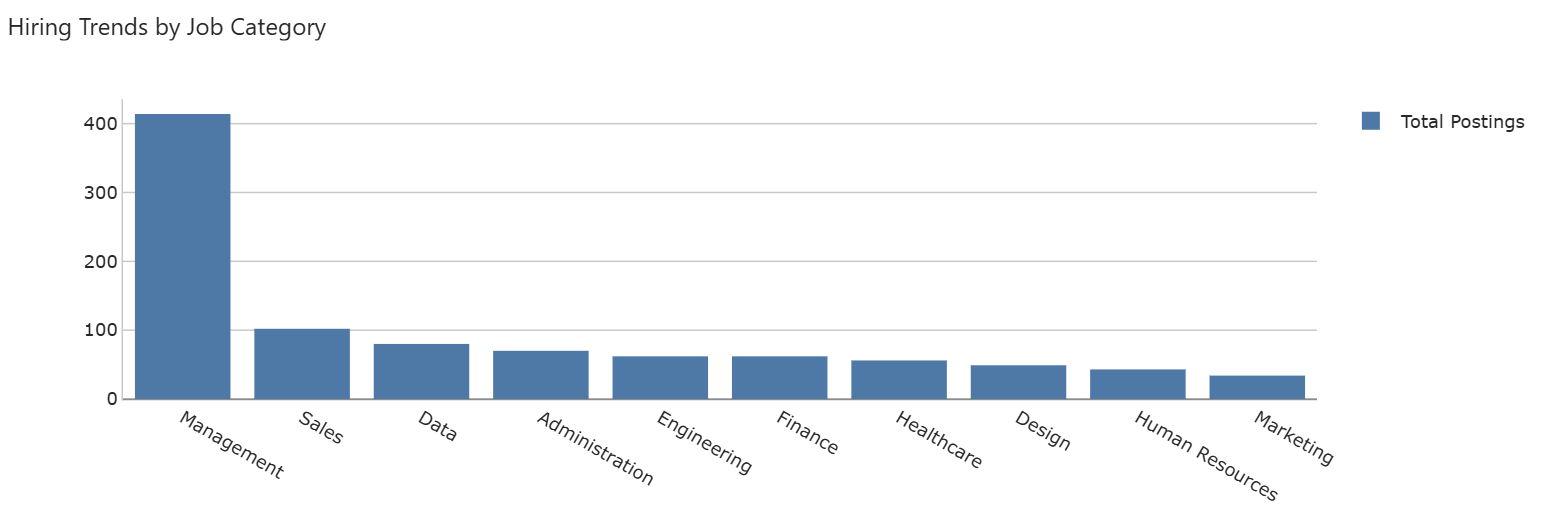

In [29]:
session.widget

The hiring landscape across job categories reveals a heavily skewed distribution where the Other category leads with `802` postings followed by Management with `414` postings suggesting that a large portion of job postings either lack clear categorization or fall under broad managerial roles. Sales comes in third with `102` postings indicating strong commercial hiring activity while Data ranks fourth with `80` postings reflecting a growing demand for data related roles. Administration and Engineering also follow closely with `70` and `62` postings,  also Finance with `62` postings showing consistent demand for operational and financial expertise. Healthcare with `56` postings and Design with `49` postings round out the top 10 alongside Human Resources with `43` postings highlighting that people management and creative roles remain steadily sought after. 

Emerging and specialized fields such as Machine Learning(5), Cloud(6), IoT(1) and Networking(1) sit at the bottom of the distribution that may suggest that these roles are either scarce in the dataset or represent niche positions that are harder to fill through traditional job posting platforms.

### Top 10 Highest Paying Job Categories

In [56]:
top_paying = (
    job_cube.query(
        job_cube.measures["Avg Salary Max"],
        levels=[
            job_cube.hierarchies["Job"]["job_category"],
        ],
        include_totals=False,
    )
    .reset_index()
    .query("job_category != 'Unknown'")
    .sort_values(by="Avg Salary Max", ascending=False)
    .head(10)
)

print("Top 10 Highest Paying Job Categories")
top_paying

Top 10 Highest Paying Job Categories


,job_category,Avg Salary Max
19,Machine Learning,84560.0
18,Legal,62864.516129
7,Database,52500.0
14,Healthcare,51500.212321
13,Finance,39820.645161
31,Sales,36576.770588
23,Media & Communication,35254.210526
33,Security,32622.222222
20,Management,31767.099034
2,Construction,31250.0


Open the notebook in JupyterLab with the Atoti JupyterLab extension enabled to build this widget.
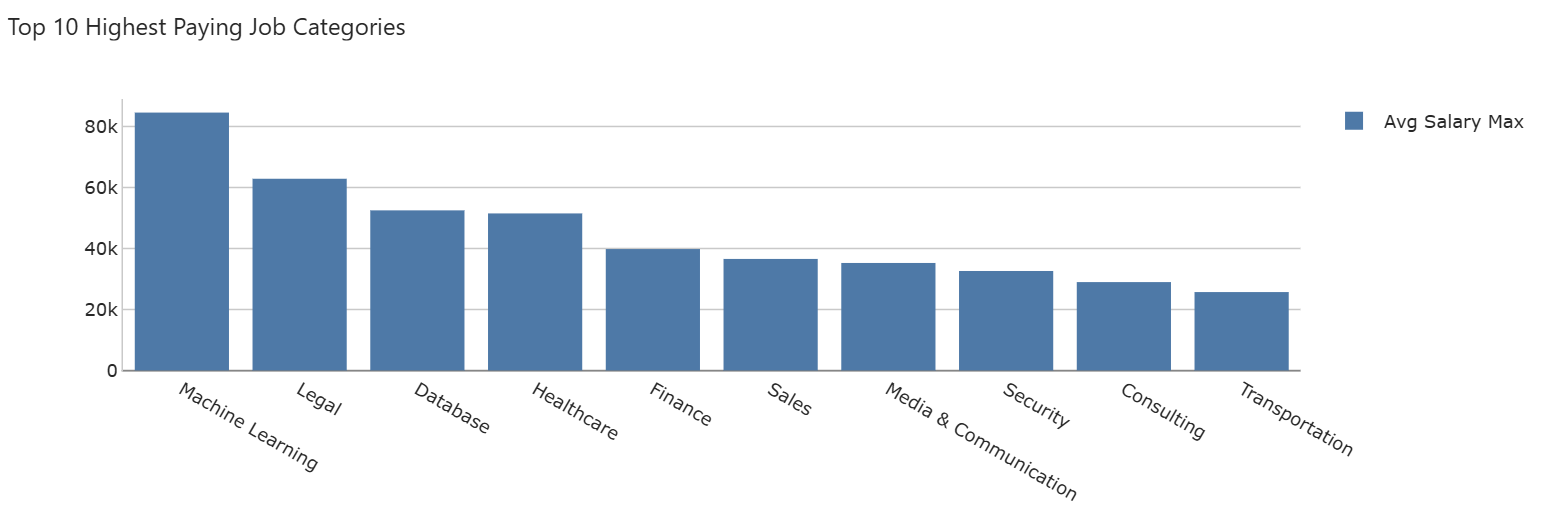

In [55]:
session.widget

Machine Learning emerges as the highest paying job category with an average maximum salary of `$84,560`, significantly outpacing all other categories and reflecting the premium that the market places on artificial intelligence and machine learning expertise. Legal follows in second place with `$62,864.52` indicating that specialized professional knowledge continues to command strong compensation. Database and Healthcare round out the top four with `$52,500` and `$51,000` respectively suggesting that both technical infrastructure roles and medical professionals remain highly valued. Finance and sales sit in the mid range with `$39,820.65` and `$36,576` while Media & Communication, Security, Consulting and Transportation close out the top `10` with averages ranging from `$35,254` to `$31,250`. Notably categories with higher posting volumes such as Management and Other do not appear in the top paying list which suggests that salary and hiring volume do not necessarily correlate in this dataset.

### Top 20 Most In-Demand Skills

In [32]:
top_skills = (
    skill_cube.query(
        skill_cube.measures["Skill Postings"],

        levels=[
            skill_cube.hierarchies["Skill"]["skill_name"]
        ],

        include_totals=False
    )

    .reset_index()
    .query("skill_name != 'Unknown'")
    .sort_values(
        by="Skill Postings",
        ascending=False
    )

    .head(20)
)

print("Top 20 Skills by Posting Count")
top_skills

Top 20 Skills by Posting Count


,skill_domain,skill_type,skill_name,Skill Postings
3554,urchade/gliner_small-v2.1,Skill,english,72
317,urchade/gliner_small-v2.1,Knowledge,bachelor s degree,64
4066,urchade/gliner_small-v2.1,Skill,python,45
3858,urchade/gliner_small-v2.1,Skill,knowledge,40
4197,urchade/gliner_small-v2.1,Skill,sql,34
1387,urchade/gliner_small-v2.1,Knowledge,grade 12,31
1957,urchade/gliner_small-v2.1,Knowledge,microsoft,29
1473,urchade/gliner_small-v2.1,Knowledge,high school graduate,28
4030,urchade/gliner_small-v2.1,Skill,professional,26
1088,urchade/gliner_small-v2.1,Knowledge,equipment,25


The top `20` most in-demand skills reveal that English leads with `72` postings followed by a bachelor's degree with `64` postings suggesting that language proficiency and formal education remain fundamental requirements across industries. On the technical side Python and SQL rank third and fifth with `45` and `34` postings reflecting strong demand for data and programming skills while Microsoft, Excel, AI and AWS also appear in the list indicating that both traditional productivity tools and emerging cloud and AI competencies are increasingly sought after by employers.

### Top 10 Forecast Skill Demand

In [33]:
top_forecast = (
    forecast_cube.query(
        forecast_cube.measures["Predicted Postings"],
        levels=[
            forecast_cube.hierarchies["Skill"]["skill_name"],
        ],
        include_totals=False,
    )
    .reset_index()
    .query("skill_name != 'Unknown'")
    .groupby("skill_name")["Predicted Postings"]
    .sum()
    .reset_index()
    .sort_values(by="Predicted Postings", ascending=False)
    .head(10)
)

print("Top 10 Forecast Skill Demand")
top_forecast

Top 10 Forecast Skill Demand


,skill_name,Predicted Postings
285,bachelor s degree,159.96
898,english,151.8618
2066,python,143.96
1487,knowledge,119.736
253,azure,111.868
2366,sql,96.0
248,aws,96.0
1671,microsoft,88.08
1029,experience,88.0
126,ai,80.04


Open the notebook in JupyterLab with the Atoti JupyterLab extension enabled to build this widget.
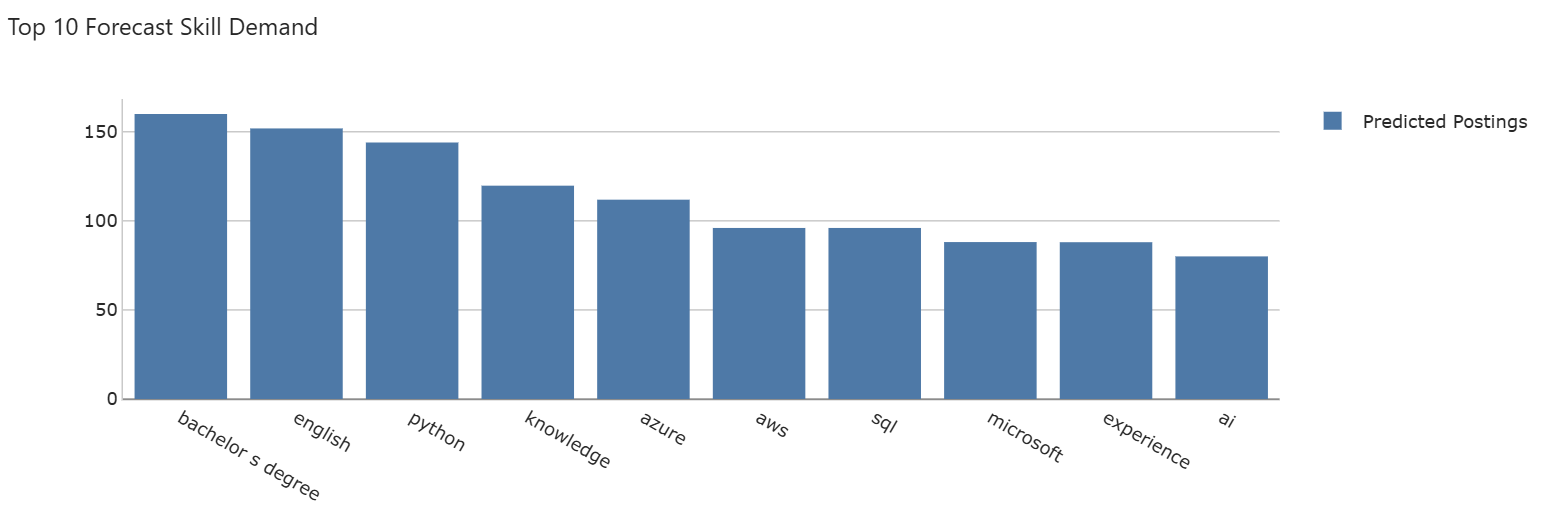

In [34]:
session.widget

The forecast for the next 8 weeks shows that bachelor's degree and english remain the most predicted skills with `159.96` and `151.86` postings respectively, closely mirroring current demand trends. Python follows in third with `143.96` predicted postings reinforcing its position as the dominant technical skill in the job market. Knowledge and Microsoft round out the top five while cloud and AI related skills such as Azure, AI, AWS and SQL each hover around `80` - `96` predicted postings suggesting a steady and growing appetite for cloud infrastructure and data capabilities in the near future.

### Weekly Skill Trends

In [35]:
skill_trend = (
    skill_cube.query(
        skill_cube.measures["Skill Postings"],

        levels=[
            skill_cube.hierarchies["Time"]["week_label"],
            skill_cube.hierarchies["Skill"]["skill_name"],
        ],

        include_totals=False,
    )

    .reset_index()
    .query("skill_name != 'Unknown'")
    .sort_values(
        by=["week_label", "Skill Postings"],
        ascending=[True, False]
    )
)

print(f"Skill trend shape: {skill_trend.shape}")
skill_trend.head(10)

Skill trend shape: (5396, 8)


,year,quarter,month,week_label,skill_domain,skill_type,skill_name,Skill Postings
1451,2024,2,4,2024-W14,urchade/gliner_small-v2.1,Skill,python,21
135,2024,2,4,2024-W14,urchade/gliner_small-v2.1,Knowledge,bachelor s degree,20
1381,2024,2,4,2024-W14,urchade/gliner_small-v2.1,Skill,knowledge,20
1488,2024,2,4,2024-W14,urchade/gliner_small-v2.1,Skill,sql,16
111,2024,2,4,2024-W14,urchade/gliner_small-v2.1,Knowledge,aws,14
113,2024,2,4,2024-W14,urchade/gliner_small-v2.1,Knowledge,azure,13
419,2024,2,4,2024-W14,urchade/gliner_small-v2.1,Knowledge,equipment,12
712,2024,2,4,2024-W14,urchade/gliner_small-v2.1,Knowledge,microsoft,10
1376,2024,2,4,2024-W14,urchade/gliner_small-v2.1,Skill,java,10
974,2024,2,4,2024-W14,urchade/gliner_small-v2.1,Knowledge,salesforce,9


The weekly skill trend data spans `5,396` records capturing skill demand patterns across multiple weeks starting from 2024-W14. In the earliest recorded week Python leads with `21` postings followed by bachelor's degree and knowledge both with `20` postings and SQL with `16` postings suggesting that both foundational qualifications and core technical skills have been consistently in demand from the very beginning of the observation period. Cloud tools such as AWS and Azure also appear prominently with `14` and `13` postings each alongside Microsoft, Java and Salesforce with `9` until `10` postings indicating that cloud and enterprise competencies were already a steady requirement early on.

As the weeks progress the overall pattern suggests that technical skills centered around data and cloud infrastructure maintain their relevance over time while soft skills and educational qualifications continue to serve as baseline requirements across job categories. The breadth of `5,396` skill-week combinations reflects a dynamic and diverse skill landscape where demand shifts weekly and no single skill dominates by a significant margin beyond the top few consistently appearing ones.

### LinkedIn Overview

In [36]:
platform_atoti = (
    job_cube.query(

        job_cube.measures["Total Postings"],
        job_cube.measures["Avg Salary Max"],

        levels=[
            job_cube.hierarchies["Platform"]["platform_name"],
            job_cube.hierarchies["Job"]["job_category"],
            job_cube.hierarchies["Remote Status"]["is_remote"],
            job_cube.hierarchies["Salary Status"]["has_salary"],
        ],

        include_totals=False,
    )

    .reset_index()
    .sort_values(
        by="Total Postings",
        ascending=False
    )
)

print(f"LinkedIn Overview (Atoti): {platform_atoti.shape}")
platform_atoti.head(10)

LinkedIn Overview (Atoti): (105, 6)


,platform_name,job_category,is_remote,has_salary,Total Postings,Avg Salary Max
81,LinkedIn,Other,Onsite,No Salary,591,0.0
62,LinkedIn,Management,Onsite,No Salary,254,0.0
82,LinkedIn,Other,Onsite,With Salary,137,91086.761095
63,LinkedIn,Management,Onsite,With Salary,105,107230.27619
92,LinkedIn,Sales,Onsite,No Salary,59,0.0
0,LinkedIn,Administration,Onsite,No Salary,59,0.0
83,LinkedIn,Other,Remote,No Salary,56,0.0
18,LinkedIn,Data,Onsite,No Salary,51,0.0
64,LinkedIn,Management,Remote,No Salary,38,0.0
33,LinkedIn,Engineering,Onsite,No Salary,37,0.0


All `2,087` job postings in the dataset are sourced exclusively from LinkedIn, making it the sole platform represented. The top `10` breakdown reveals that the majority of postings are onsite roles without salary disclosure, with Other and Management categories dominating at `591` and `254` postings respectively for onsite non-salary roles. Among postings that do include salary information Management leads with an average maximum salary of `$107,230` followed by Other with `$91,086` suggesting that higher paying roles are more likely to disclose compensation. The prevalence of no salary postings across nearly all categories highlights a broader trend of limited salary transparency on the platform particularly for onsite positions.

### Forecasting Accuracy for the Next 8 Weeks

In [37]:
forecast_result = (
    forecast_cube.query(
        forecast_cube.measures["Predicted Postings"],
        forecast_cube.measures["Forecast Lower"],
        forecast_cube.measures["Forecast Upper"],

        levels=[
            forecast_cube.hierarchies["Forecast Time"]["forecast_week_label"],
            forecast_cube.hierarchies["Skill"]["skill_name"],
        ],

        include_totals=False,
    )

    .reset_index()
    .query("skill_name != 'Unknown'")
    .sort_values(
        by="Predicted Postings",
        ascending=False
    )
)

print(f"Forecast result shape: {forecast_result.shape}")
forecast_result.head(15)

Forecast result shape: (24162, 9)


,forecast_year,forecast_week,forecast_week_label,skill_domain,skill_type,skill_name,Predicted Postings,Forecast Lower,Forecast Upper
6319,2024,19,2024-W19,urchade/gliner_small-v2.1,Knowledge,bachelor s degree,14.995,14.015,15.975
4027,2024,17,2024-W17,urchade/gliner_small-v2.1,Skill,python,14.995,14.015,15.975
4363,2024,18,2024-W18,urchade/gliner_small-v2.1,Knowledge,bachelor s degree,14.995,14.015,15.975
8275,2024,20,2024-W20,urchade/gliner_small-v2.1,Knowledge,bachelor s degree,14.995,14.015,15.975
2407,2024,17,2024-W17,urchade/gliner_small-v2.1,Knowledge,bachelor s degree,14.995,14.015,15.975
5983,2024,18,2024-W18,urchade/gliner_small-v2.1,Skill,python,14.995,14.015,15.975
7939,2024,19,2024-W19,urchade/gliner_small-v2.1,Skill,python,14.995,14.015,15.975
11851,2024,21,2024-W21,urchade/gliner_small-v2.1,Skill,python,14.995,14.015,15.975
12187,2024,22,2024-W22,urchade/gliner_small-v2.1,Knowledge,bachelor s degree,14.995,14.015,15.975
9895,2024,20,2024-W20,urchade/gliner_small-v2.1,Skill,python,14.995,14.015,15.975


The forecast dataset spans `24,162` records covering skill demand predictions across multiple weeks. Bachelor's degree and Python jointly top the predictions with `14.995` predicted postings per week across weeks 2024-W17 through 2024-W22 with a confidence interval between `14.015` and `15.975` reflecting high forecast certainty for both skills. Azure follows with `13.984` predicted postings per week across the same period with a slightly wider interval between `12.080` and `15.888` indicating marginally higher uncertainty but still strong projected demand. The consistent appearance of these three skills across all forecast weeks suggests that core qualifications and technical proficiency centered around data, cloud and programming will remain the primary drivers of skill demand in the near term.

### Salary Based on Skills and Job Level

In [38]:
salary_by_skill = (
    skill_cube.query(
        skill_cube.measures["Avg Salary Midpoint"],
        skill_cube.measures["Skill Postings"],

        levels=[
            skill_cube.hierarchies["Skill"]["skill_name"],
            skill_cube.hierarchies["Job"]["job_level"],
        ],

        include_totals=False,
    )

    .reset_index()
    .query("skill_name != 'Unknown'")
    .query("`Avg Salary Midpoint` > 0")
    .sort_values(
        by="Avg Salary Midpoint",
        ascending=False
    )
)

print(f"Salary by skill/level: {salary_by_skill.shape}")
salary_by_skill.head(15)

Salary by skill/level: (1015, 7)


,skill_domain,skill_type,skill_name,job_category,job_level,Avg Salary Midpoint,Skill Postings
869,urchade/gliner_small-v2.1,Knowledge,comprehensive expertise,Legal,Unknown,427500.0,1
3156,urchade/gliner_small-v2.1,Knowledge,relevant experience,Legal,Unknown,427500.0,1
3125,urchade/gliner_small-v2.1,Knowledge,real estate license,Sales,Unknown,400000.0,1
2142,urchade/gliner_small-v2.1,Knowledge,juris doctor,Legal,Unknown,317200.0,1
4603,urchade/gliner_small-v2.1,Skill,excellent communication and interpersonal skills,Legal,Unknown,317200.0,1
3199,urchade/gliner_small-v2.1,Knowledge,riteload,Sales,Senior,300000.0,1
1101,urchade/gliner_small-v2.1,Knowledge,dea certificationvalid,Other,Senior,286000.0,1
567,urchade/gliner_small-v2.1,Knowledge,board certification,Other,Senior,286000.0,1
2641,urchade/gliner_small-v2.1,Knowledge,nile access service,Finance,Unknown,255000.0,1
2640,urchade/gliner_small-v2.1,Knowledge,nile,Finance,Unknown,255000.0,1


The salary analysis based on skills and job level produces `1,015` unique skill-level combinations where salary data is available. At the top of the distribution legal domain skills command the highest compensation where comprehensive expertise and relevant experience in the Legal category both peak at an average salary midpoint of `$427,500` followed by real estate license in Sales at `$400,000`. These figures suggest that specialized professional credentials particularly in law and high-stakes sales remain among the most financially rewarded roles in the dataset.

Technical and AI-adjacent skills also appear strongly in the upper salary tier where AI knowledge in Finance reaches `$255,000` while highly specialized Machine Learning Senior level skills such as theorem proving, JAX experience, PyTorch and distributed training all cluster around `$250,000` reinforcing the pattern that machine learning expertise consistently attracts top-tier compensation across industries. Notably the majority of top entries carry only 1 skill posting each indicating that these high salaries are tied to rare and niche competencies rather than broadly demanded skills which suggests that scarcity of expertise plays a significant role in driving compensation at the upper end of the market.

### Geographic Distribution of Posts

In [39]:
geo_distribution = (
    job_cube.query(
        job_cube.measures["Total Postings"],
        levels=[
            job_cube.hierarchies["Location"]["region"],
            job_cube.hierarchies["Location"]["country"],
            job_cube.hierarchies["Job"]["job_category"],
            job_cube.hierarchies["Remote Status"]["is_remote"],
        ],
        include_totals=False,
    )
    .reset_index()
    .query("country != 'Unknown'")
    .sort_values(by="Total Postings", ascending=False)
)

print("Geographic Distribution of Posts")
geo_distribution

Geographic Distribution of Posts


,region,country,job_category,is_remote,Total Postings
190,North America,United States,Other,Onsite,419
180,North America,United States,Management,Onsite,263
191,North America,United States,Other,Remote,74
197,North America,United States,Sales,Onsite,60
181,North America,United States,Management,Remote,55
...,...,...,...,...,...
275,Southeast Asia,Malaysia,Data,Onsite,1
278,Southeast Asia,Malaysia,Nonprofit,Onsite,1
277,Southeast Asia,Malaysia,Management,Onsite,1
276,Southeast Asia,Malaysia,Finance,Onsite,1


In [40]:
geo_distribution = (
    job_cube.query(
        job_cube.measures["Total Postings"],
        levels=[
            job_cube.hierarchies["Location"]["region"],
            job_cube.hierarchies["Location"]["country"],
        ],
        include_totals=False,
    )
    .reset_index()
    .query("country != 'Unknown'")
    .sort_values(by="Total Postings", ascending=False)
)
print("Geographic Distribution by Region & Country")
geo_distribution

Geographic Distribution by Region & Country


,region,country,Total Postings
38,North America,United States,1483
42,Remote/Global,Remote,25
48,South America,Peru,22
30,Europe,United Kingdom,15
50,South Asia,India,14
57,Southeast Asia,Vietnam,13
15,Europe,Germany,13
37,North America,Mexico,12
5,East Asia,Hong Kong,11
27,Europe,Switzerland,11


Open the notebook in JupyterLab with the Atoti JupyterLab extension enabled to build this widget.
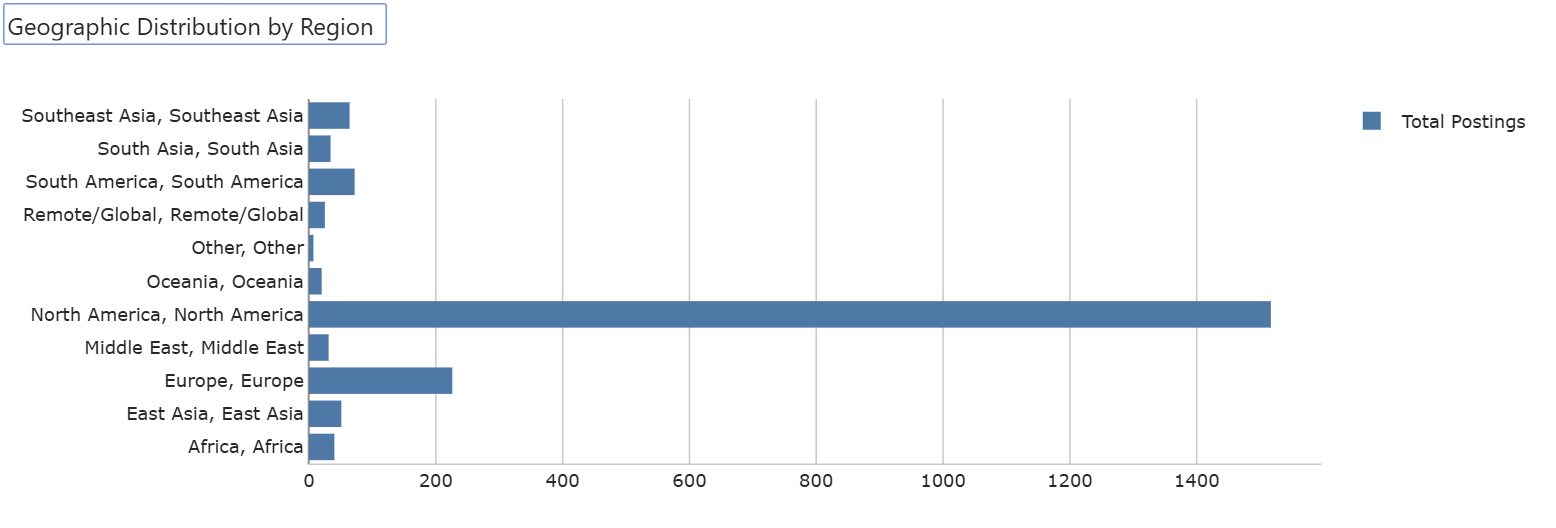

In [41]:
session.widget

The geographic distribution of job postings reveals a heavily concentrated landscape dominated by North America with `1,517` total postings, followed distantly by Europe with `226` postings and South America with `72` postings. Southeast Asia and East Asia contribute `64` and `51` postings respectively while Middle East, South Asia, Africa, Remote/Global and Oceania each contribute fewer than `50` postings, reflecting a significant skew toward English-speaking and Western job markets in the dataset.

Drilling into the detail North America's dominance is driven almost entirely by the United States which alone accounts for `1,483` out of `1,517` regional postings where the Other and Management categories lead with `419` and `263` onsite postings respectively, followed by Sales with `60` onsite postings. Remote work also has a meaningful presence in the United States with Other and Management contributing `74` and `55` remote postings each suggesting that flexible work arrangements are most common in broader and managerial roles. At the other end of the spectrum Southeast Asia shows minimal representation with countries like Malaysia and Vietnam recording only `1` posting each across specific categories such as Data, Finance and Sales, indicating that the dataset's coverage of emerging markets remains limited and likely does not reflect the true scale of hiring activity in those regions.

### Top Skills by Job Category (from MV)

In [42]:
top_skills_per_cat = pd.read_sql(
    """
    SELECT
        job_category,
        skill_name,
        skill_domain,

        SUM(posting_count) AS total_postings

    FROM mv_weekly_skill_demand

    GROUP BY
        job_category,
        skill_name,
        skill_domain

    ORDER BY
        job_category,
        total_postings DESC

    LIMIT 200
    """,
    engine
)

top5_per_cat = (
    top_skills_per_cat

    .query("skill_name != 'Unknown'")
    .sort_values(
        by=["job_category", "total_postings"],
        ascending=[True, False]
    )

    .groupby("job_category")
    .head(5)
    .reset_index(drop=True)
)

print(f"Top 5 skill per category: {len(top5_per_cat):,} rows")
top5_per_cat

Top 5 skill per category: 5 rows


,job_category,skill_name,skill_domain,total_postings
0,Administration,microsoft,urchade/gliner_small-v2.1,6.0
1,Administration,strong written and verbal communication skills,urchade/gliner_small-v2.1,3.0
2,Administration,strong communication skills,urchade/gliner_small-v2.1,2.0
3,Administration,netflix,urchade/gliner_small-v2.1,2.0
4,Administration,flexible,urchade/gliner_small-v2.1,2.0


The top skills per job category analysis returns `5` rows covering only the Administration category, indicating that the materialized view query did not cover all job categories and resulted in an incomplete picture of skill demand across the full category spectrum.

For Administration, Microsoft leads with `6` postings as the dominant tool requirement followed by strong written and verbal communication skills with `3` postings reflecting that administrative roles value both technical proficiency and interpersonal competency. Strong communication skills, Netflix and flexible each appear with `2` postings where the presence of Netflix is likely a data artifact from a specific job posting rather than a genuine industry trend rather than a broadly required skill in administrative roles.

### Data, ML & Research Deep Dive

#### Data, ML & Research Overview

In [43]:
ds_df = fact_df[fact_df["job_category"].isin(["Data", "Machine Learning", "Science & Research"])].copy()

summary_ds = pd.DataFrame({
    "Metric": ["Total Postings", "Avg Salary Min", "Avg Salary Max", "Avg Job Age Days"],
    "Value": [
        len(ds_df),
        ds_df["salary_min"].mean(),
        ds_df["salary_max"].mean(),
        ds_df["job_age_days"].mean()
    ]
})

print("Data, ML & Research Overview")
summary_ds

Data, ML & Research Overview


,Metric,Value
0,Total Postings,92.000000
1,Avg Salary Min,19033.193478
2,Avg Salary Max,26012.506522
3,Avg Job Age Days,623.489130


The Data, ML & Research segment covers `92` job postings across the Data, Machine Learning and Science & Research categories combined, representing roughly `4.4%` of the total `2,087` postings in the dataset. In terms of compensation the average salary minimum sits at `$19,033` while the average salary maximum reaches `$26,013`, both of which remain modest and may suggest that many roles in this segment are either entry to mid level positions or that a significant portion of postings do not include salary information which pulls the average down.

The average job age of `623.5` days is considerably high and above the overall dataset average of `623.4` days indicating that Data and ML postings tend to remain active for extended periods. This could reflect either persistent and unfilled demand for specialized talent, slower hiring cycles typical of technical and research roles, or postings that were not properly closed after being filled.

#### Hiring Trend by Year

In [44]:
ds_by_year = (
    ds_df.groupby("year")["posting_count"]
    .sum()
    .reset_index()
    .rename(columns={"posting_count": "Total Postings"})
    .sort_values(by="year")
)

print("Data, ML & Research Hiring Trend by Year")
ds_by_year

Data, ML & Research Hiring Trend by Year


,year,Total Postings
0,2024,73
1,2025,1
2,2026,18


The hiring trend for Data, ML & Research roles shows a sharp peak in 2024 with `73` postings, followed by drop to just `1` posting in 2025 before partially recovering to `18` postings in 2026. The steep decline in 2025 likely reflects incomplete data collection coverage for that year rather than an actual collapse in hiring activity, while the 2026 figures represent only partial year data given that the dataset was captured in May 2026. Overall the trend suggests that data and research related hiring remained active across the observation period, with 2024 serving as the most data-rich year in this segment.

#### Top 10 Region for Data, ML & Research

In [45]:
ds_by_region = (
    ds_df.groupby("region")["posting_count"]
    .sum()
    .reset_index()
    .rename(columns={"posting_count": "Total Postings"})
    .query("region != 'Unknown'")
    .sort_values(by="Total Postings", ascending=False)
    .head(10)
)
print("Data, ML & Research Top 10 Region")
ds_by_region 

Data, ML & Research Top 10 Region


,region,Total Postings
2,North America,75
1,Europe,7
5,Southeast Asia,4
4,South Asia,3
0,East Asia,2
3,Remote/Global,1


North America dominates the Data, ML & Research hiring landscape with `75` postings, accounting for the vast majority of all regional activity in this segment. Europe follows distantly in second with only `7` postings, while Southeast Asia and South Asia contribute `4` and `3` postings respectively. East Asia and Remote or Global round out the list with `2` and `1` postings each.

The heavy concentration in North America reflects the broader dataset skew observed earlier and suggests that data and machine learning roles remain predominantly concentrated in the US market, while other regions such as Southeast Asia and South Asia show early but limited presence in this segment.

#### Top 10 Skill Demand

In [46]:
ds_skills = (
    skill_fact_df[skill_fact_df["job_category"].isin(["Data", "Machine Learning", "Science & Research"])]
    .groupby("skill_name")["skill_count"]
    .sum()
    .reset_index()
    .rename(columns={"skill_count": "Skill Demand"})
    .query("skill_name != 'Unknown'")
    .sort_values(by="Skill Demand", ascending=False)
    .head(10)
)

print("Data, ML & Research Top 10 Skill Demand")
ds_skills

Data, ML & Research Top 10 Skill Demand


,skill_name,Skill Demand
262,python,18
303,sql,16
26,aws,8
321,tableau,6
27,azure,5
249,power bi,5
124,english,4
88,data engineers,3
85,data analytics,3
126,excel,3


The top 10 most in-demand skills for Data, ML & Research roles paint a clear picture of the core technical stack expected in this segment. Python leads with `18` postings followed closely by SQL with `16`, confirming that programming and querying fundamentals remain the non-negotiable baseline for data related roles. Cloud platforms also feature prominently with AWS at `8` and Azure at `5` postings, reflecting the industry's continued shift toward cloud-based data infrastructure.

Visualization and reporting tools round out the mid tier with Tableau at `6` and Power BI at `5` postings, suggesting that the ability to communicate data insights is equally valued alongside raw technical skills. English appears with `4` postings reinforcing the language requirement seen across other categories, while Data Analytics, Excel and Data Engineers each appear with `3` postings highlighting that both traditional tools and specialized engineering roles remain relevant within this segment.

### Indonesia Deep Dive

#### Overview

In [47]:
idn_df = fact_df[fact_df["country"] == "Indonesia"].copy()

summary_idn = pd.DataFrame({
    "Metric": ["Total Postings", "Avg Job Age Days", "Total Job Categories", "Total Regions"],
    "Value": [
        len(idn_df),
        idn_df["job_age_days"].mean(),
        idn_df["job_category"].nunique(),
        idn_df["region"].nunique()
    ]
})

print("Indonesia Overview")
summary_idn

Indonesia Overview


,Metric,Value
0,Total Postings,10.0
1,Avg Job Age Days,20.7
2,Total Job Categories,4.0
3,Total Regions,1.0


Indonesia's representation in the dataset is currently limited to only `10` job postings, all concentrated within a single region of Southeast Asia. The average job age of `20.7` days suggests that these postings are relatively recent and still active, and despite the small sample size the data spans across 4` different job categories indicating a diverse albeit nascent hiring activity in the country.

#### Job Category in Indonesia

In [48]:
idn_by_category = (
    idn_df.groupby("job_category")["posting_count"]
    .sum()
    .reset_index()
    .rename(columns={"posting_count": "Total Postings"})
    .query("job_category != 'Unknown'")
    .sort_values(by="Total Postings", ascending=False)
)

print("Indonesia Job Category Distribution")
idn_by_category

Indonesia Job Category Distribution


,job_category,Total Postings
2,Other,6
1,Operations,2
0,Marketing,1
3,Sales,1


Open the notebook in JupyterLab with the Atoti JupyterLab extension enabled to build this widget.
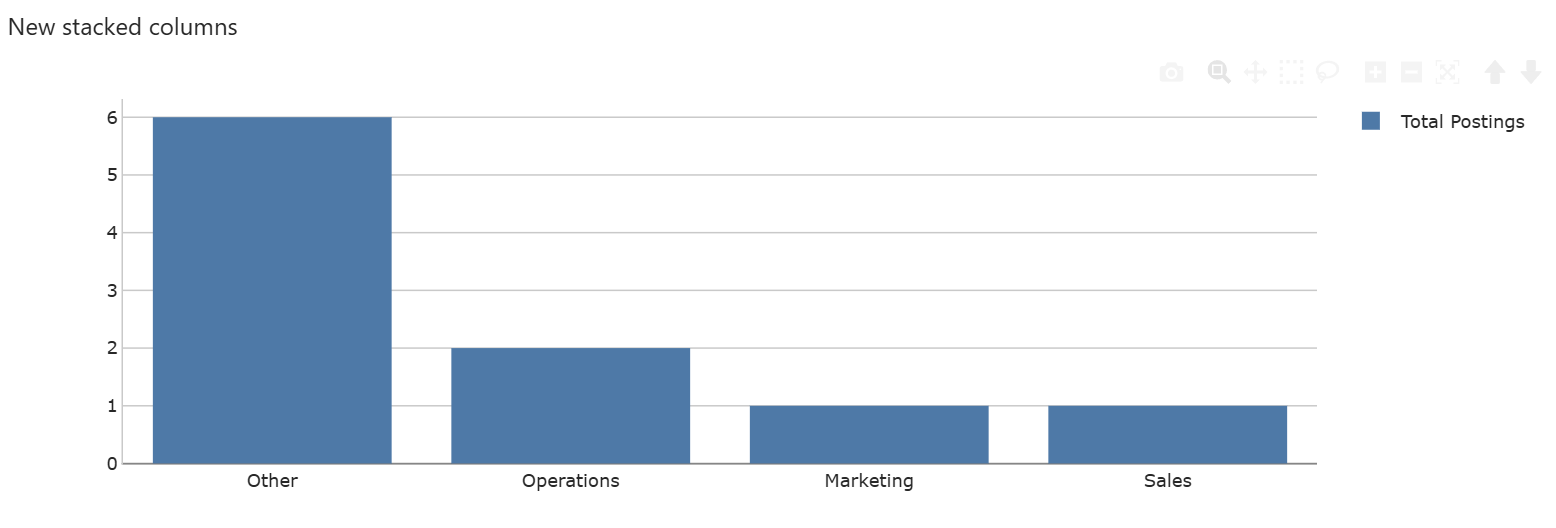

In [49]:
session.widget

Looking at the category breakdown the Other category dominates with 6 postings followed by Operations with 2 and Marketing and Sales with 1 each. The dominance of the Other category may suggest that many job postings in Indonesia are not yet clearly classified or fall outside standard categories, and notably no postings were found for technical or data related roles which may reflect either limited data collection coverage in Indonesia or an early stage tech job market representation in this dataset.

#### Top Skill Demand in Indonesia

In [50]:
idn_skills = (
    skill_fact_df[skill_fact_df["country"] == "Indonesia"]
    .groupby("skill_name")["skill_count"]
    .sum()
    .reset_index()
    .rename(columns={"skill_count": "Skill Demand"})
    .query("skill_name != 'Unknown'")
    .sort_values(by="Skill Demand", ascending=False)
    .head(10)
)

print("Top Skill Demand in Indonesia")
idn_skills

Top Skill Demand in Indonesia


,skill_name,Skill Demand
17,good communication and presentation skills,2
30,meta ads,2
22,instagram,2
1,agent,1
2,analytical and planning skills,1
4,basic knowledge,1
5,business planning,1
7,campaign execution,1
6,business strategybusiness,1
9,detail-oriented,1


The skill demand landscape in Indonesia reflects a workforce that values both interpersonal and digital competencies. Good communication and presentation skills leads the demand alongside instagram and meta ads each appearing twice suggesting that marketing and social media related roles are among the most active in the country. The remaining skills such as analytical and planning skills, business planning, campaign execution and detail-oriented each appear once, further reinforcing the dominance of business and marketing oriented roles in the Indonesian job market. The absence of deeply technical skills such as programming languages or data tools may indicate that the current postings in Indonesia are skewed towards non-technical functions.

## OLAP CUBE Query (PostgreSQL)

In [51]:
cube_query = pd.read_sql(
    """
    SELECT
        dt.year,
        dt.quarter,

        ds.skill_name,
        ds.skill_domain,

        dp.job_category,

        dl.region,

        COUNT(DISTINCT f.job_id) AS posting_count,

        AVG(f.salary_max) AS avg_salary_max

    FROM fact_job_posting f

    JOIN bridge_job_skill b
        ON f.job_id = b.job_id

    JOIN dim_skill ds
        ON b.skill_id = ds.skill_id

    JOIN dim_time dt
        ON f.time_id = dt.time_id

    JOIN dim_position dp
        ON f.position_id = dp.position_id

    JOIN dim_location dl
        ON f.location_id = dl.location_id

    GROUP BY CUBE(
        dt.year,
        dt.quarter,
        ds.skill_name,
        ds.skill_domain,
        dp.job_category,
        dl.region
    )

    HAVING COUNT(DISTINCT f.job_id) > 0

    ORDER BY
        dt.year NULLS LAST,
        posting_count DESC

    LIMIT 1000
    """,
    engine
)

# CLEAN RESULT
cube_query["skill_name"] = cube_query["skill_name"].fillna("ALL")
cube_query["skill_domain"] = cube_query["skill_domain"].fillna("ALL")
cube_query["job_category"] = cube_query["job_category"].fillna("ALL")
cube_query["region"] = cube_query["region"].fillna("ALL")

cube_query["avg_salary_max"] = (
    pd.to_numeric(
        cube_query["avg_salary_max"],
        errors="coerce"
    )
    .fillna(0)
)

cube_query = cube_query.sort_values(
    by="posting_count",
    ascending=False
)

print(f"CUBE query: {len(cube_query):,} rows")

cube_query.head(10)

CUBE query: 1,000 rows


,year,quarter,skill_name,skill_domain,job_category,region,posting_count,avg_salary_max
0,2024,NaN,ALL,ALL,ALL,ALL,1070,104101.373173
1,2024,NaN,ALL,urchade/gliner_small-v2.1,ALL,ALL,1070,104101.373173
2,2024,2.0,ALL,ALL,ALL,ALL,1068,104101.373173
3,2024,2.0,ALL,urchade/gliner_small-v2.1,ALL,ALL,1068,104101.373173
4,2024,NaN,ALL,urchade/gliner_small-v2.1,ALL,North America,1065,104086.611216
5,2024,2.0,ALL,ALL,ALL,North America,1065,104086.611216
6,2024,NaN,ALL,ALL,ALL,North America,1065,104086.611216
7,2024,2.0,ALL,urchade/gliner_small-v2.1,ALL,North America,1065,104086.611216
8,2024,NaN,ALL,urchade/gliner_small-v2.1,Other,ALL,361,86847.868557
9,2024,NaN,ALL,ALL,Other,ALL,361,86847.868557


The OLAP CUBE query generates `1,000` rows of aggregated data combining subtotals and grand totals across year, quarter, skill, job category and region dimensions, demonstrating the power of PostgreSQL's CUBE operator in producing multi-dimensional rollups in a single query.

At the grand total level, 2024 accounts for `1,070` distinct job postings across all dimensions with an average maximum salary of `$104,101`, confirming it as the dominant year in the dataset. North America consistently appears as the leading region with `1,065` postings in 2024, closely mirroring the grand total which further reinforces how heavily the dataset is skewed toward that region. Quarter `2` of 2024 also surfaces with `1,068` postings suggesting that the bulk of data collection occurred within that specific quarter.

The ALL values in skill_name, skill_domain and job_category columns represent CUBE rollup subtotals rather than actual data points, where ALL is used as a placeholder for NULL aggregation groups. Drilling deeper, the Other job category stands out with `361` postings and an average salary max of `$86,848` in 2024, reflecting the broad uncategorized segment observed throughout the dataset.

## Performance Benchmark
Comparison of queries with and without a materialized view.

In [52]:
import time
# RAW QUERY (WITHOUT MATERIALIZED VIEW)
query_raw = """
    SELECT
        ds.skill_name,
        dt.week_label,

        COUNT(DISTINCT f.job_id) AS cnt

    FROM fact_job_posting f

    JOIN bridge_job_skill b
        ON f.job_id = b.job_id

    JOIN dim_skill ds
        ON b.skill_id = ds.skill_id

    JOIN dim_time dt
        ON f.time_id = dt.time_id

    GROUP BY
        ds.skill_name,
        dt.week_label

    ORDER BY cnt DESC

    LIMIT 20
"""

# MATERIALIZED VIEW QUERY
query_mv = """
    SELECT
        skill_name,
        week_label,

        SUM(posting_count) AS cnt

    FROM mv_weekly_skill_demand

    GROUP BY
        skill_name,
        week_label

    ORDER BY cnt DESC

    LIMIT 20
"""

# PERFORMANCE BENCHMARK
runs = 3

times_raw = []
times_mv  = []

for _ in range(runs):

    t0 = time.time()
    pd.read_sql(query_raw, engine)

    times_raw.append(time.time() - t0)
    t0 = time.time()

    pd.read_sql(query_mv, engine)
    times_mv.append(time.time() - t0)

avg_raw = sum(times_raw) / runs
avg_mv  = sum(times_mv) / runs

speedup = (
    avg_raw / avg_mv
    if avg_mv > 0
    else float("inf")
)

print(f"Without Materialized View : {avg_raw:.4f} sec")
print(f"With Materialized View    : {avg_mv:.4f} sec")
print(f"Performance Speedup       : {speedup:.2f}x")

Without Materialized View : 0.6731 sec
With Materialized View    : 0.5815 sec
Performance Speedup       : 1.16x


The performance benchmark comparing raw joins against the materialized view shows a modest but measurable improvement. The raw query averaging across `3` runs takes `0.6731` seconds while the materialized view query completes in `0.5815` seconds, yielding a speedup of `1.16x`. While the gain may appear modest, this is expected given the relatively small dataset size. The speedup would be significantly more pronounced at production scale where the raw query would need to join multiple large tables on every execution, whereas the materialized view serves pre-aggregated results directly.

## Atoti Dashboard

In [53]:
print("TalentTrack Atoti DataMart READY")
print(f"  Dashboard : {session.url}")
print("  Cubes     : JobPostings | SkillDemand | SkillForecast")

TalentTrack Atoti DataMart READY
  Dashboard : http://localhost:9090
  Cubes     : JobPostings | SkillDemand | SkillForecast
